# Hypnograms

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import copy
import matplotlib.pyplot as plt

## Parameters

In [3]:
with open("params_analysis.yml") as f:
    params = yaml.safe_load(f)
### AUX = params['aux']

DATA_FOLDER = params['data_folder']
DATES = params['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes'

## Functions

In [4]:
def plot_area_hypno(df_list,title='',areas_list=[]):
    """
    Plotting hypnograms per area (further merging probabilities per array).
    """
    areas = np.unique(np.array(areas_list))
    num_areas = len(areas)

    ### merging DFs per area
    df_dict = {}
    for area in areas:
        #print(area)
        df_dict[area] = []
        if area in ['V4','IT']:
            areas_idx = np.where(np.array(areas_list)==area)[0]
        else:
            ar_list = ['V1','V2']
            areas_idx = [i for i, a in enumerate(areas) if a in ar_list]

        #print(areas_idx)
        for i in areas_idx:
            df_dict[area].append(df_list[i])
    for area in areas:
        dfs_to_merge = df_dict[area]
        df_dict[area] = sum(dfs_to_merge) / len(dfs_to_merge)
    
    fig, ax = plt.subplots(num_areas,1)
    fig.set_figwidth(6)
    fig.set_figheight(num_areas*1.5)

    for row in range(num_areas):
        axi = ax[row]
        area = areas[row]
        df_aux = df_dict[area]

        prob_matrix = df_aux[['W','R','N1','N2','N3']].values.T

        axi.set_title(f'{title}, {area}')
        axi.imshow(prob_matrix,cmap='BuPu',aspect='auto',interpolation='none',vmin=0, vmax=1)
        axi.set_yticks(range(5))
        axi.set_yticklabels(['W','R','N1','N2','N3'])
        axi.set_xticks([])
        axi.set_xticklabels([])

    plt.tight_layout()
    plt.show()
    plt.close()
    
    return

## Plotting

### Monkey L

In [5]:
MONKEY = 'L'
AREAS_MONKEY = params['areas'][MONKEY]

20170725
Num. bins:45
Time of rec. used: 1350 s


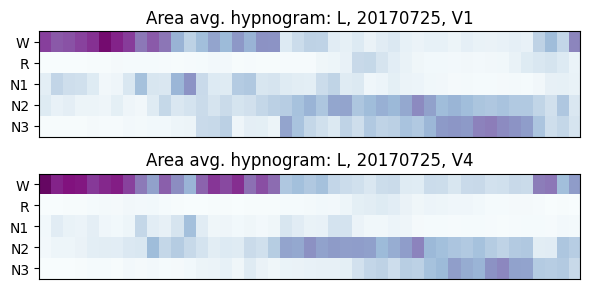

20170809
Num. bins:44
Time of rec. used: 1320 s


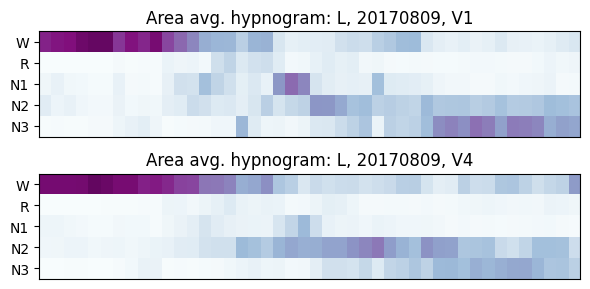

20170810
Num. bins:43
Time of rec. used: 1290 s


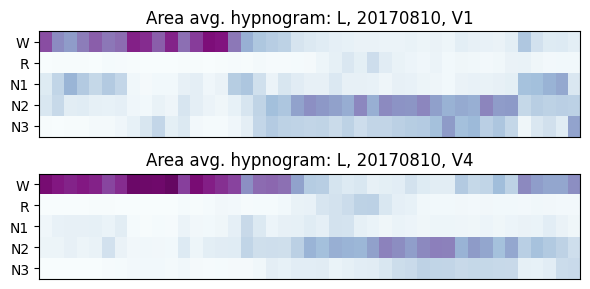

In [6]:
for date in params['dates'][MONKEY]['RS']:
    print(date)
    df_list = []
    for array in range(1,17):
        df_aux = pd.read_csv(f'{DF_FOLDER}/hypnograms/{MONKEY}/hypnogram_30s_{MONKEY}_{date}_array_{array}.csv',)
        df_list.append(df_aux)
    print(f'Num. bins:{df_list[0].shape[0]}')
    print(f'Time of rec. used: {30*df_list[0].shape[0]} s')
    ### V1 and V2 pooled together
    plot_area_hypno(df_list,title=f'Area avg. hypnogram: {MONKEY}, {date}',areas_list=AREAS_MONKEY)

### Monkey N

In [7]:
MONKEY = 'N'
AREAS_MONKEY = params['areas'][MONKEY]

20240719_B1
Num. bins:41
Time of rec. used: 1230 s


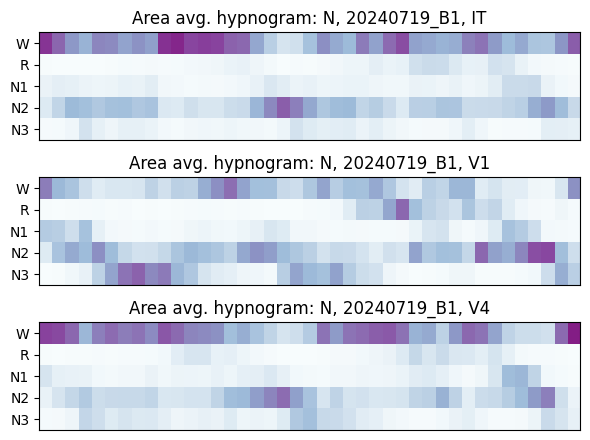

20240719_B2
Num. bins:40
Time of rec. used: 1200 s


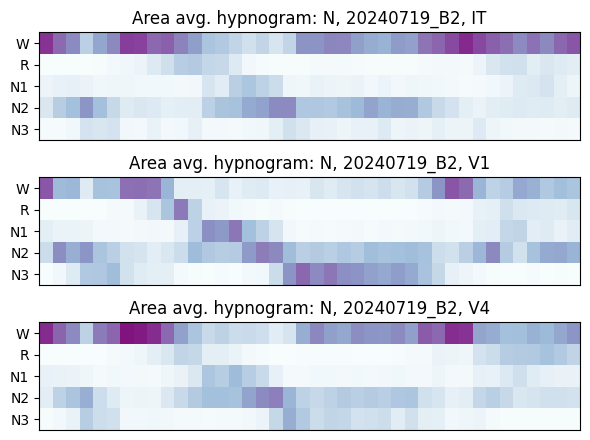

In [8]:
for date in params['dates'][MONKEY]['RS']:
    print(date)
    df_list = []
    for array in range(1,17):
        df_aux = pd.read_csv(f'{DF_FOLDER}/hypnograms/{MONKEY}/hypnogram_30s_{MONKEY}_{date}_array_{array}.csv',)
        df_list.append(df_aux)
    print(f'Num. bins:{df_list[0].shape[0]}')
    print(f'Time of rec. used: {30*df_list[0].shape[0]} s')
    ### V1 and V2 pooled together
    plot_area_hypno(df_list,title=f'Area avg. hypnogram: {MONKEY}, {date}',areas_list=AREAS_MONKEY)

### Monkey F

In [9]:
MONKEY = 'F'
AREAS_MONKEY = params['areas'][MONKEY]

20240122_B1
Num. bins:22
Time of rec. used: 660 s


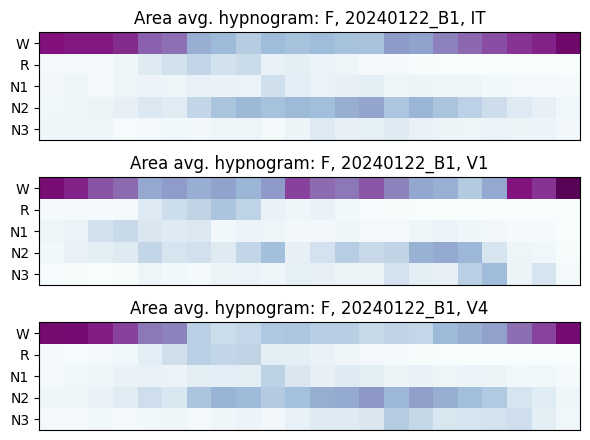

20241216_B1
Num. bins:20
Time of rec. used: 600 s


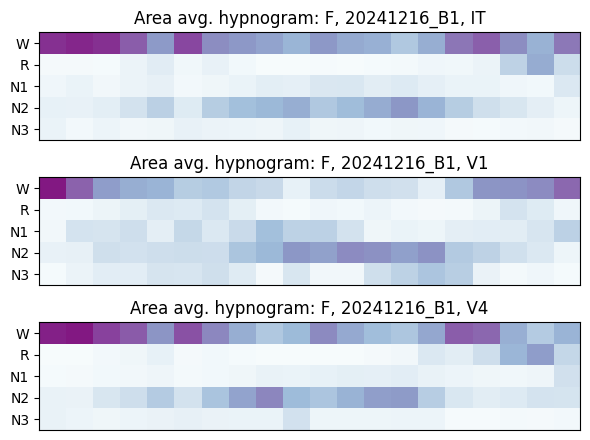

In [10]:
for date in params['dates'][MONKEY]['RS']:
    print(date)
    df_list = []
    for array in range(1,17):
        df_aux = pd.read_csv(f'{DF_FOLDER}/hypnograms/{MONKEY}/hypnogram_30s_{MONKEY}_{date}_array_{array}.csv',)
        df_list.append(df_aux)
    print(f'Num. bins:{df_list[0].shape[0]}')
    print(f'Time of rec. used: {30*df_list[0].shape[0]} s')
    ### V1 and V2 pooled together
    plot_area_hypno(df_list,title=f'Area avg. hypnogram: {MONKEY}, {date}',areas_list=AREAS_MONKEY)